# Extreme aerosol event detection (dust, smoke ,etc) from PACE polarimetric L2 products

**POC/Reviewers:** Meng Gao (NASA GSFC 616, SSAI), Kirk Knobelspiesse (NASA GSFC 616)

[edl]: https://urs.earthdata.nasa.gov/
[oci-data-access]: https://oceancolor.gsfc.nasa.gov/resources/docs/tutorials/notebooks/oci_data_access/

## Summary
This notebook demonstrate the detection of high AOD events, and expore the optical and microphysical properties. The data products are based on the HARP2 Level 2 (L2) aerosol product derived from the joint aerosol and surface retrieval algorithm: FastMAPOL 

### load modules

In [2]:
import earthaccess
import requests

import os
import sys
import glob
import shutil
import numpy as np
import xarray as xr

import argparse
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from pathlib import Path
from matplotlib import rcParams

#update the path of the tools
mapol_path=os.path.expanduser('~/github/mapoltool')
sys.path.append(mapol_path)

from tools.detection_html_all import *
from tools.detection_plot_map import *
from tools.detection_util import *
from tools.detection_download import *

from matplotlib import rcParams

import earthaccess

/accounts/mgao1/miniforge3/envs/py3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


===load fastmapol function===


### setup system, download l2 data

In [3]:
auth = earthaccess.login(persist=True)
    
# Change default font to something available
rcParams['font.family'] = 'serif' 
rcParams['font.size'] = '12' 

tspan = ("2025-09-15", "2025-09-15")
day1 = tspan[0]+'_'+tspan[1]

data_path, l1c_path, plot_path, html_path = setup_data(tspan)


short_name="PACE_HARP2_L2_MAPOL_OCEAN_NRT"

filelist_l2 = download_l2_cloud(tspan, short_name=short_name)
nfile = len(filelist_l2)
print("total file before selection", nfile)

QUEUEING TASKS | : 100%|███████████████████████████████████████████| 147/147 [00:00<00:00, 5059.76it/s]
PROCESSING TASKS | : 100%|███████████████████████████████████████████| 147/147 [01:25<00:00,  1.72it/s]
COLLECTING RESULTS | : 100%|█████████████████████████████████████| 147/147 [00:00<00:00, 244279.99it/s]

total file before selection 147


### select data

In [5]:
aod_min = 0.3
npixel_min = 100*100
filev2 = select_data(filelist_l2, aod_min=aod_min, npixel_min=npixel_min)
nfile = len(filev2)
print("total file after selection", nfile)

/accounts/mgao1/github/jupyter_notebook/t21_rapid_response/data/2025-09-26-d6d4d6/PACE_HARP2.20250915T084120.L2.MAPOL_OCEAN.V3_0.NRT.nc
total valid pixel, valid pixel selected: 31952 19125
/accounts/mgao1/github/jupyter_notebook/t21_rapid_response/data/2025-09-26-d6d4d6/PACE_HARP2.20250915T100941.L2.MAPOL_OCEAN.V3_0.NRT.nc
total valid pixel, valid pixel selected: 52064 23761
/accounts/mgao1/github/jupyter_notebook/t21_rapid_response/data/2025-09-26-d6d4d6/PACE_HARP2.20250915T101941.L2.MAPOL_OCEAN.V3_0.NRT.nc
total valid pixel, valid pixel selected: 13135 11537
/accounts/mgao1/github/jupyter_notebook/t21_rapid_response/data/2025-09-26-d6d4d6/PACE_HARP2.20250915T133121.L2.MAPOL_OCEAN.V3_0.NRT.nc
total valid pixel, valid pixel selected: 35351 28743
/accounts/mgao1/github/jupyter_notebook/t21_rapid_response/data/2025-09-26-d6d4d6/PACE_HARP2.20250915T150941.L2.MAPOL_OCEAN.V3_0.NRT.nc
total valid pixel, valid pixel selected: 46413 33735
/accounts/mgao1/github/jupyter_notebook/t21_rapid_respo

### make plot test

/accounts/mgao1/github/jupyter_notebook/t21_rapid_response/data/2025-09-26-d6d4d6/PACE_HARP2.20250915T084120.L2.MAPOL_OCEAN.V3_0.NRT.nc
20250915T084120
PACE_HARP2.20250915T084120.L1C.V3.5km.nc
data_l1c/2025-09-15_2025-09-15/PACE_HARP2.20250915T084120.L1C.V3.5km.nc
./plot/2025-09-15_2025-09-15/20250915T084120/
./plot/2025-09-15_2025-09-15/20250915T084120/pace_harp2_20250915T084120_globe.png
Central Latitude: 15.045897483825684, Central Longitude: 60.955108642578125


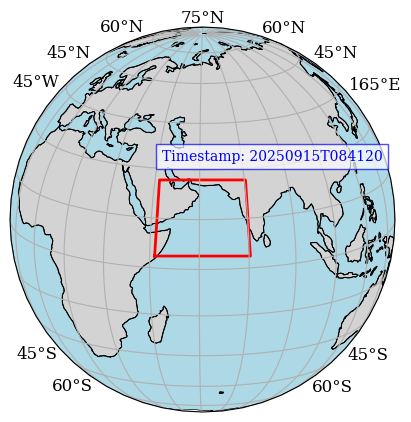

./plot/2025-09-15_2025-09-15/20250915T084120/pace_harp2_20250915T084120_rgb.png
./plot/2025-09-15_2025-09-15/20250915T084120/pace_harp2_20250915T084120_aot.png
./plot/2025-09-15_2025-09-15/20250915T084120/pace_harp2_20250915T084120_ssa.png
./plot/2025-09-15_2025-09-15/20250915T084120/pace_harp2_20250915T084120_fvf.png
./plot/2025-09-15_2025-09-15/20250915T084120/pace_harp2_20250915T084120_sph.png


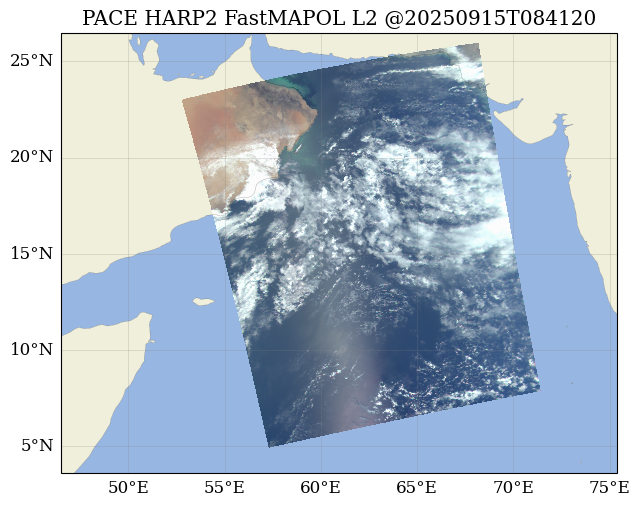

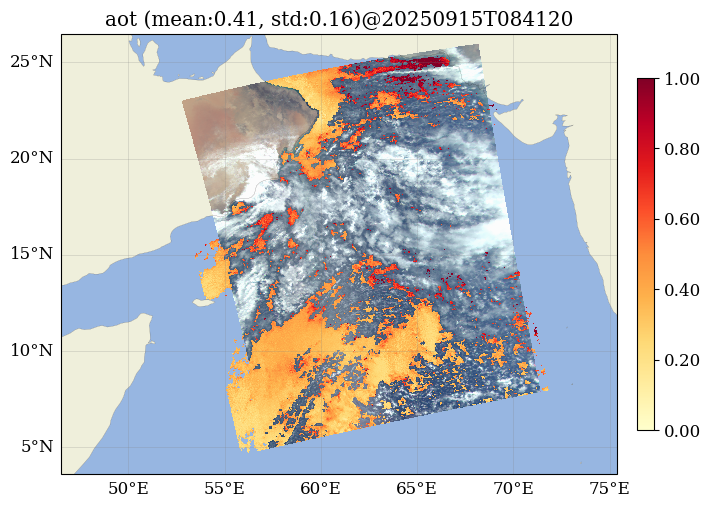

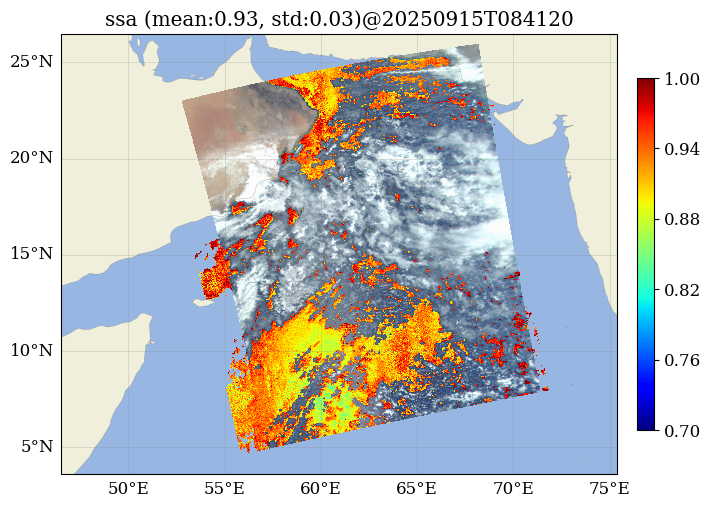

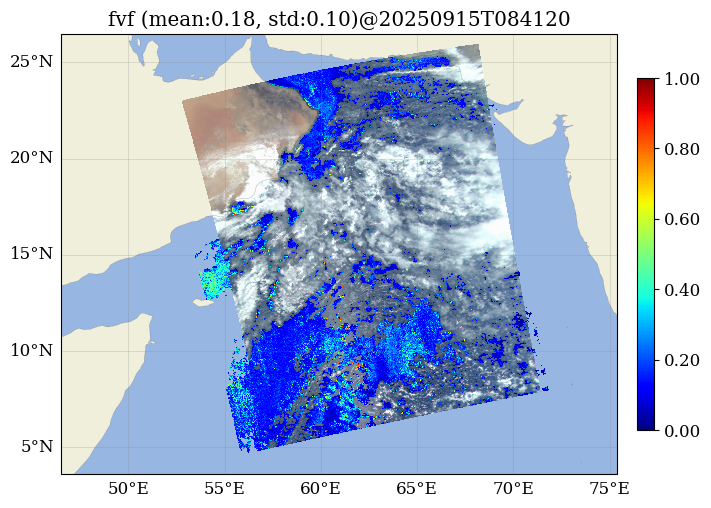

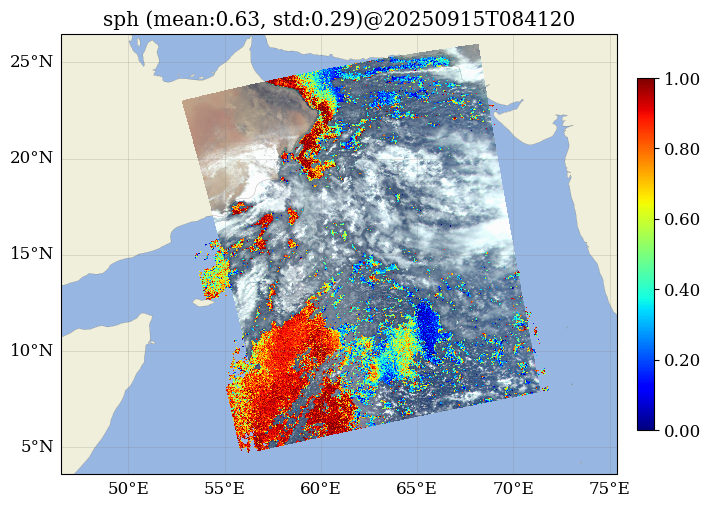

In [6]:
file1 = filev2[0]
plot_l1c_l2(filev2[0], plot_path, l1c_path=l1c_path)

### make plot for all selected granules

#run this code when need download all granules
#note large number of plots may be generated
#or call this function directly:
#make_plot(filev2, plot_path, l1c_path)

def make_plot(filev2, plot_path, l1c_path="./data/", flag_cloud=True):
    """generate plots according to filev2"""
    
    os.makedirs(plot_path, exist_ok=True)
    os.makedirs(l1c_path, exist_ok=True)
    
    for file1 in filev2[:]:
        try:
            plot_l1c_l2(file1, plot_path, l1c_path=l1c_path, flag_cloud=flag_cloud)
        except:
            print('failed', file1)

### create html for sharing

In [8]:
output_file = html_path+"harp2_fastmapol_"+day1+'_n'+str(nfile)+".html"

sequence = [['globe', 'rgb', 'aot', ], ['ssa', 'fvf', 'sph']]
titlev_custom = [["", "", "AOD (550nm)"], ["Single Scattering Albedo (550nm)", 
                                           "Fine Mode Volume Fraction", "Spherical Fraction"]]

#title = 'PACE Rapid Response on HARP2 FastMAPOL L2:\n
#    {} granule found for valid #pixel > {} (when aod(550nm) > {})'.format(nfile, npixel_min, aod_min)

title = "PACE HARP2 FastMAPOL L2 Rapid Response:{}-{}".format(tspan[0], tspan[1])
title2 = "Total {} granule found for valid #pixel > {} (when aod(550nm) > {})".format(nfile, npixel_min, aod_min)
             
print(title)
print(title2)

image_groups = get_images_from_subfolders(plot_path)
create_html_from_subfolders(image_groups, output_file, sequence, title=title, title2=title2,
                             titlev=titlev_custom, resolution_factor=2, quality=75)

PACE HARP2 FastMAPOL L2 Rapid Response:2025-09-15-2025-09-15
Total 6 granule found for valid #pixel > 10000 (when aod(550nm) > 0.3)
create html 20250915T084120
create html 20250915T100941
create html 20250915T101941
create html 20250915T133121
create html 20250915T150941
✅ Combined HTML gallery written to ./html/harp2_fastmapol_2025-09-15_2025-09-15_n6.html


### clean up downloaded files, do not add them into repo

share html on:
https://oceancolor.gsfc.nasa.gov/fileshare/meng_gao/rapid_pace